# Profile likelihood for discrete-time LTI: KF vs Taylor-KF vs PF

This **deep dive** builds a **profile likelihood** for a single parameter (one entry of the $A$ matrix) in a discrete-time LTI system. All other parameters are **known** (no biases). Controls are simulated i.i.d. from $\mathcal{N}(0,1)$. We compare the profile log-likelihood computed with:

- **KF** (exact Kalman filter, dynamax)
- **taylor_kf** (Taylor-linearized Kalman filter, cuthbert)
- **PF** (bootstrap particle filter, cuthbert)

**Setup:** 2 states, 1 control, 1 output. We learn $\alpha = A_{0,0}$; $A_{1,1}$ and $B$, $H$, $R$, $Q$ are fixed.

## Imports and config

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    Condition,
    Context,
    DiscreteTimeSimulator,
    DynamicalModel,
    FilterBasedMarginalLogLikelihood,
    LinearGaussianObservation,
    LinearGaussianStateEvolution,
    Trajectory,
)

# Dimensions: 2 states, 1 control, 1 output
state_dim = 2
control_dim = 1
observation_dim = 1

## LTI model: one learned parameter $\alpha = A_{0,0}$, no biases

We set $A = \begin{bmatrix} \alpha & 0 \\ 0 & 0.8 \end{bmatrix}$, $B$, $H$, $R$, $Q$ fixed. Biases $b$, $d$ are zero.

In [2]:
def lti_one_param_model():
    """Discrete-time LTI: only alpha = A[0,0] is sampled; all else fixed, no biases."""
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))
    A = jnp.array([[alpha, 0.0], [0.0, 0.8]])
    Q = 0.1 * jnp.eye(state_dim)
    H = jnp.array([[1.0, 0.0]])
    R = jnp.array([[0.5**2]])
    initial_mean = jnp.zeros(state_dim)
    initial_cov = jnp.eye(state_dim)
    B = jnp.array([[0.1], [0.0]])
    D = jnp.array([[0.01]])
    # No biases
    b = jnp.zeros(state_dim)
    d = jnp.zeros(observation_dim)
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(initial_mean, initial_cov),
        state_evolution=LinearGaussianStateEvolution(A=A, B=B, bias=b, cov=Q),
        observation_model=LinearGaussianObservation(H=H, D=D, bias=d, R=R),
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
    )
    dsx.sample("f", dynamics)

## True parameter, observation times, and controls $u_t \sim \mathcal{N}(0,1)$

In [3]:
true_alpha = 0.4
obs_times = jnp.arange(0.0, 1000.0, 1.0)
T = len(obs_times)

key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)
# Controls i.i.d. N(0,1)
ctrl_values = jr.normal(key_ctrl, shape=(T, control_dim))
control_trajectory = Trajectory(times=obs_times, values=ctrl_values)

print("True alpha:", true_alpha)
print("Observation times length:", T)
print("Controls shape:", ctrl_values.shape)

True alpha: 0.4
Observation times length: 1000
Controls shape: (1000, 1)


## Generate synthetic observations

Simulate the model with true $\alpha$ and the control trajectory to get $y_{1:T}$.

In [4]:
context_for_sim = Context(
    observations=Trajectory(times=obs_times),
    controls=control_trajectory,
)
predictive = Predictive(
    lti_one_param_model,
    params={"alpha": jnp.array(true_alpha)},
    num_samples=1,
    exclude_deterministic=False,
)

with DiscreteTimeSimulator():
    with Condition(context_for_sim):
        synthetic = predictive(key_data)

obs_values = synthetic["observations"].squeeze(0)
observation_trajectory = Trajectory(times=obs_times, values=obs_values)
context = Context(
    observations=observation_trajectory,
    controls=control_trajectory,
)
print("Observations shape:", obs_values.shape)

Observations shape: (1000, 1)


## Profile log-likelihood

For each filter type (KF, taylor_kf, PF), we compute $\log p(y_{1:T} \mid \alpha)$ by running `Predictive` with `params={"alpha": alpha}`. The marginal log-likelihood is the `f_marginal_loglik` deterministic site. We `vmap` over the grid of $\alpha$ values.

**Note:** The PF profile is stochastic (one random key per run). Re-run the PF cell with a different key to see variability. KF and taylor_kf are deterministic for this LTI model.

In [5]:
alpha_min, alpha_max = -0.6, 0.6
n_grid = 61
alpha_grid = jnp.linspace(alpha_min, alpha_max, n_grid)


def make_model(filter_type):
    """Build data-conditioned model with given filter type."""

    def model():
        with FilterBasedMarginalLogLikelihood(
            filter_type=filter_type, n_filter_particles=2000
        ):
            with Condition(context):
                return lti_one_param_model()

    return model


def get_marginal_loglik(alpha_val, key, filter_type):
    """Run Predictive with fixed alpha; return f_marginal_loglik site."""
    model = make_model(filter_type)
    pred = Predictive(
        model,
        params={"alpha": jnp.array(alpha_val)},
        num_samples=1,
        exclude_deterministic=False,
    )
    out = pred(key)
    return out["f_marginal_loglik"].squeeze()


def profile_log_likelihood(filter_type, alpha_vals, key=jr.PRNGKey(0)):
    """Profile log p(y | alpha) via vmap over Predictive + f_marginal_loglik. Returns (profile_array, time_seconds)."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    profile = jax.vmap(
        lambda a, k: get_marginal_loglik(a, k, filter_type),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed

In [6]:
profile_kf, t_kf = profile_log_likelihood("kf", alpha_grid)
profile_taylor_kf, t_taylor_kf = profile_log_likelihood("taylor_kf", alpha_grid)
profile_pf, t_pf = profile_log_likelihood("pf", alpha_grid)
profile_ekf, t_ekf = profile_log_likelihood("ekf", alpha_grid)
profile_ukf, t_ukf = profile_log_likelihood("ukf", alpha_grid)

timings = {"KF": t_kf, "taylor_kf": t_taylor_kf, "PF": t_pf, "EKF": t_ekf, "UKF": t_ukf}
profiles = {
    "KF": profile_kf,
    "taylor_kf": profile_taylor_kf,
    "PF": profile_pf,
    "EKF": profile_ekf,
    "UKF": profile_ukf,
}

print("Filter      | max profile ll  | time (s)")
print("------------|-----------------|--------")
for name in ["KF", "taylor_kf", "PF", "EKF", "UKF"]:
    ll = float(jnp.nanmax(profiles[name]))
    print(f"{name:11} | {ll:15.4f} | {timings[name]:.3f}")

Filter      | max profile ll  | time (s)
------------|-----------------|--------
KF          |       -907.5437 | 0.383
taylor_kf   |       -907.5437 | 2.067
PF          |       -907.0673 | 10.465
EKF         |       -907.5437 | 0.686
UKF         |       -907.5437 | 0.184


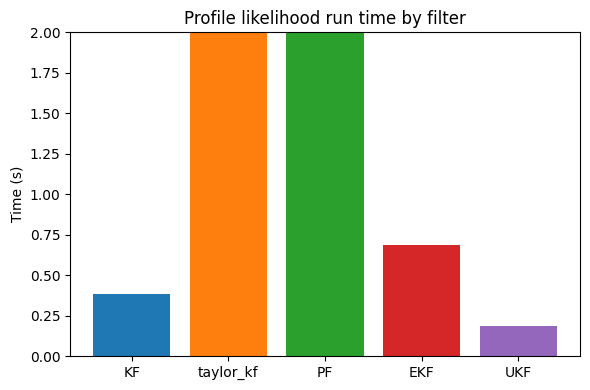

In [7]:
# Bar chart of profile likelihood run times
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
names = list(timings.keys())
times = [timings[n] for n in names]
ax.bar(names, times, color=["C0", "C1", "C2", "C3", "C4"])
ax.set_ylabel("Time (s)")
ax.set_ylim([0, 2])
ax.set_title("Profile likelihood run time by filter")
plt.tight_layout()
plt.show()

## Plot profile log-likelihoods

All three filters should peak near the true $\alpha = 0.4$. KF is exact for this LTI; taylor_kf is a linearization; PF is a Monte Carlo approximation.

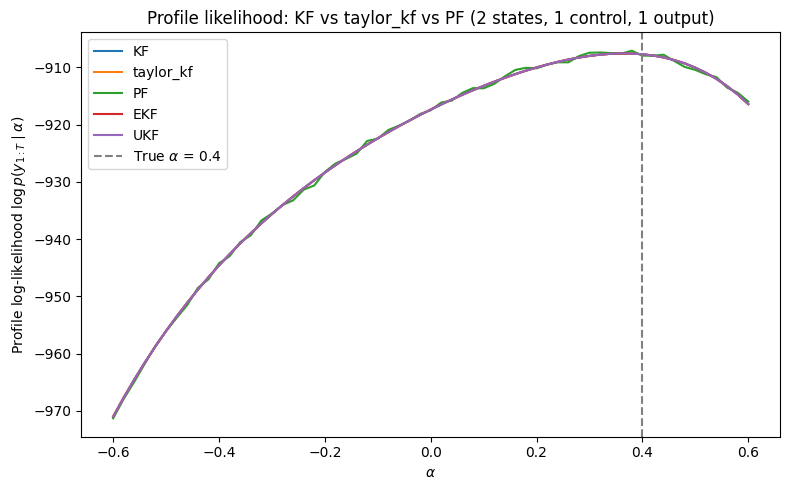

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.array(alpha_grid), np.array(profile_kf), label="KF", color="C0")
ax.plot(
    np.array(alpha_grid), np.array(profile_taylor_kf), label="taylor_kf", color="C1"
)
ax.plot(np.array(alpha_grid), np.array(profile_pf), label="PF", color="C2")
ax.plot(np.array(alpha_grid), np.array(profile_ekf), label="EKF", color="C3")
ax.plot(np.array(alpha_grid), np.array(profile_ukf), label="UKF", color="C4")
ax.axvline(
    true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}"
)
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile log-likelihood $\\log p(y_{1:T} \\mid \\alpha)$")
ax.legend()
ax.set_title(
    "Profile likelihood: KF vs taylor_kf vs PF (2 states, 1 control, 1 output)"
)
plt.tight_layout()
plt.show()